In [80]:
# Global Config

RUNNING_NEW_RENO = True
CWND_CSV_PATH = "cwnd_output.csv"
RTT_CSV_PATH = "rtt_output.csv"

In [81]:
%pip install statsmodels

# Congestion Control

Data sliced to start at index 300003 (First Event: TIMEOUT)


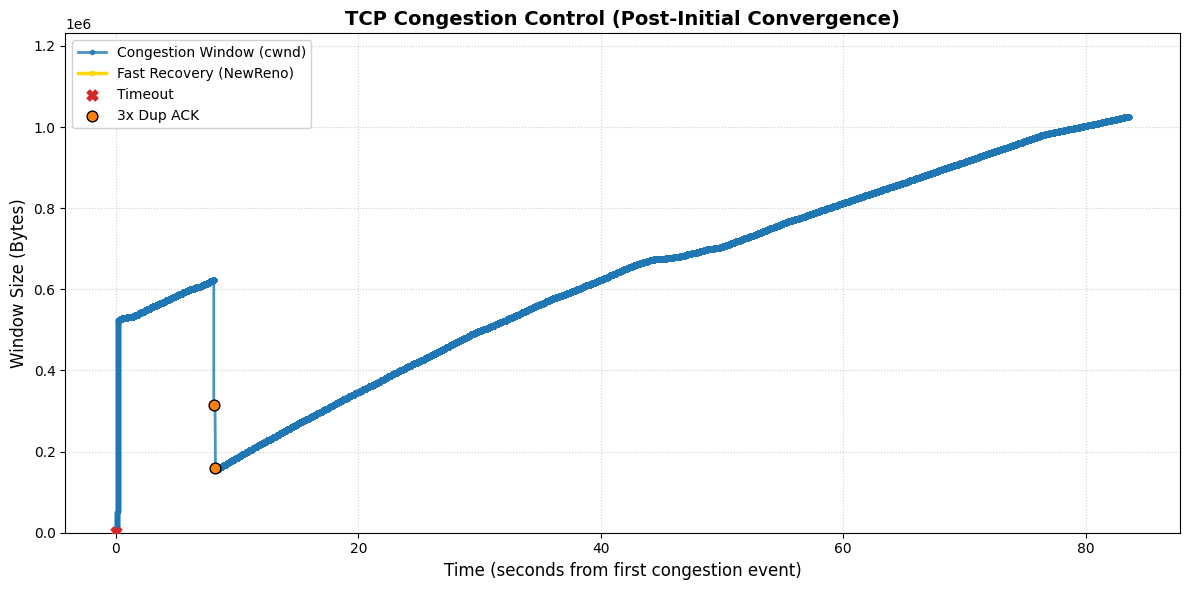

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV data
column_names = ['Timestamp', 'Event', 'CWND', 'SSTHRESH']

try:
    df = pd.read_csv('cwnd_output.csv', names=column_names, header=None)
except FileNotFoundError:
    print("Error: cwnd_output.csv not found.")
    exit(1)

# 2. Clean and identify the "Start Point"
# Convert to numeric to ensure math operations work
df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')
df['SSTHRESH'] = pd.to_numeric(df['SSTHRESH'], errors='coerce')

# Find the index of the first congestion event (TIMEOUT or TRIPLE_DUP_ACK)
trigger_events = df.index[df['Event'].isin(['TRIPLE_DUP_ACK', 'TIMEOUT'])].tolist()
had_congestion = bool(trigger_events)

if had_congestion:
    # Start the dataframe EXACTLY at the first event
    start_idx = trigger_events[0]
    df = df.iloc[start_idx:].reset_index(drop=True)
    first_event_type = df.iloc[0]['Event']
    print(f"Data sliced to start at index {start_idx} (First Event: {first_event_type})")
else:
    print("No congestion events detected — plotting full transfer.")

# Normalize time after slicing so the graph starts at 0.0
if not df.empty:
    df['Timestamp'] = df['Timestamp'] - df['Timestamp'].iloc[0]

# Filter out only the 0xFFFFFFFF sentinel value (used for "infinity" SSTHRESH when unset).
# Do NOT cap at an arbitrary byte count — CWND can legitimately grow large on clean transfers.
SENTINEL = 0xFFFFFFFF
df['SSTHRESH_plot'] = df['SSTHRESH'].where(df['SSTHRESH'] != SENTINEL)
df['CWND_plot'] = df['CWND'].where(df['CWND'] != SENTINEL)

# Fast Recovery (NewReno Partial ACKs) Flatlining
df['CWND_display'] = df['CWND_plot'].copy()

in_fast_recovery = False
fr_cwnd_value = None
fr_segments = []
current_fr_start = None

for idx, row in df.iterrows():
    event = row['Event']

    if event == 'TRIPLE_DUP_ACK':
        in_fast_recovery = True
        fr_cwnd_value = row['CWND_plot']
        current_fr_start = idx

    elif event == 'PARTIAL_ACK' and in_fast_recovery:
        df.at[idx, 'CWND_display'] = fr_cwnd_value

    elif event in ['ACK', 'TIMEOUT'] and in_fast_recovery:
        in_fast_recovery = False
        fr_segments.append((current_fr_start, idx))

if in_fast_recovery and current_fr_start is not None:
    fr_segments.append((current_fr_start, len(df) - 1))

# 3. Create the plot
plt.figure(figsize=(12, 6))

plt.plot(df['Timestamp'], df['CWND_display'], label='Congestion Window (cwnd)',
         color='#1f77b4', linewidth=2, marker='.', markersize=6, alpha=0.8)

for i, (start_idx, end_idx) in enumerate(fr_segments):
    segment = df.iloc[start_idx:end_idx+1]
    label = 'Fast Recovery (NewReno)' if i == 0 else None
    plt.plot(segment['Timestamp'], segment['CWND_display'],
             color='gold', linewidth=2.5, marker='.', markersize=6, alpha=1.0, label=label)

# 4. Highlight the congestion events
timeouts = df[df['Event'] == 'TIMEOUT']
if not timeouts.empty:
    plt.scatter(timeouts['Timestamp'], timeouts['CWND_display'], color='#d62728',
                marker='X', s=60, label='Timeout', zorder=5)

triple_dups = df[df['Event'] == 'TRIPLE_DUP_ACK']
if not triple_dups.empty:
    plt.scatter(triple_dups['Timestamp'], triple_dups['CWND_display'], color='#ff7f0e',
                marker='o', s=60, label='3x Dup ACK', zorder=5, edgecolors='black')

# 5. Formatting
if had_congestion:
    title = 'TCP Congestion Control (Post-Initial Convergence)'
    xlabel = 'Time (seconds from first congestion event)'
else:
    title = 'TCP Congestion Control (No Congestion Events)'
    xlabel = 'Time (seconds from connection start)'

plt.title(title, fontsize=14, fontweight='bold')
plt.xlabel(xlabel, fontsize=12)
plt.ylabel('Window Size (Bytes)', fontsize=12)

if not df['CWND_display'].dropna().empty:
    ymax = df['CWND_display'].max() * 1.2
    plt.ylim(0, ymax)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', framealpha=0.9)
plt.tight_layout()

# 6. Save and show
plt.savefig('utcp_sawtooth_fixed.png', dpi=300)
plt.show()

## RTT Time Series

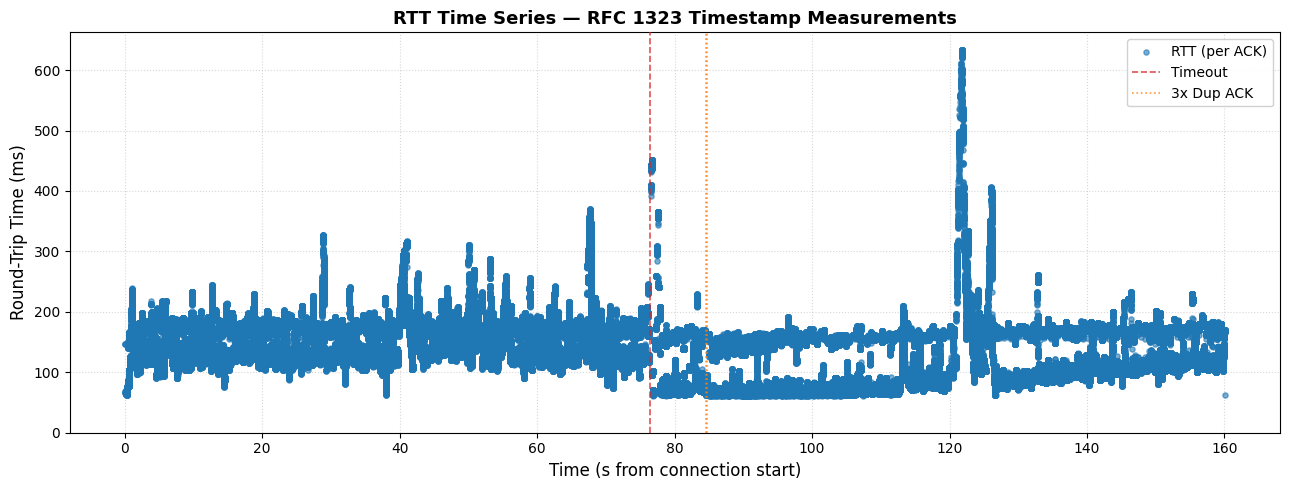

Samples: 582881 total, 582881 with RTT measurement
RTT — min: 60.58 ms  mean: 131.96 ms  max: 633.75 ms
Congestion events plotted: 3 (1 timeouts, 2 triple dup ACKs)


In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Load — columns: wallclock_epoch_s, seq, rtt_us, srtt_us, rttvar_us, rto_ms
rtt = pd.read_csv(
    RTT_CSV_PATH,
    names=['ts_epoch', 'seq', 'rtt_us', 'srtt_us', 'rttvar_us', 'rto_ms'],
    dtype={'ts_epoch': float, 'seq': int, 'rtt_us': int,
           'srtt_us': int, 'rttvar_us': int, 'rto_ms': int},
)

# Normalize time to seconds from the first sample
rtt_t0 = rtt['ts_epoch'].iloc[0]
rtt['t'] = rtt['ts_epoch'] - rtt_t0

# Convert microseconds → milliseconds for readability
rtt['rtt_ms'] = rtt['rtt_us'] / 1000

# Drop zero-RTT rows (segments timed before ts_enabled was negotiated)
measured = rtt[rtt['rtt_us'] > 0].copy()

# Load congestion events and align to the same time origin as RTT
try:
    cwnd_raw = pd.read_csv(
        CWND_CSV_PATH,
        names=['Timestamp', 'Event', 'CWND', 'SSTHRESH'],
        header=None,
    )
    cwnd_raw['Timestamp'] = pd.to_numeric(cwnd_raw['Timestamp'], errors='coerce')
    cwnd_raw['t'] = cwnd_raw['Timestamp'] - rtt_t0

    cc_events = cwnd_raw[cwnd_raw['Event'].isin(['TIMEOUT', 'TRIPLE_DUP_ACK'])]
except FileNotFoundError:
    cc_events = pd.DataFrame(columns=['t', 'Event'])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(
    measured['t'], measured['rtt_ms'],
    s=14, color='#1f77b4', alpha=0.6, zorder=3, label='RTT (per ACK)',
)

# Congestion events as vertical lines (they have a time, not a y-value)
_timeout_labeled = False
_tripledup_labeled = False
for _, row in cc_events.iterrows():
    if row['Event'] == 'TIMEOUT':
        label = 'Timeout' if not _timeout_labeled else None
        ax.axvline(row['t'], color='#d62728', linestyle='--', linewidth=1.2,
                   alpha=0.8, label=label, zorder=4)
        _timeout_labeled = True
    elif row['Event'] == 'TRIPLE_DUP_ACK':
        label = '3x Dup ACK' if not _tripledup_labeled else None
        ax.axvline(row['t'], color='#ff7f0e', linestyle=':', linewidth=1.2,
                   alpha=0.8, label=label, zorder=4)
        _tripledup_labeled = True

ax.set_xlabel('Time (s from connection start)', fontsize=12)
ax.set_ylabel('Round-Trip Time (ms)', fontsize=12)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)

plt.title('RTT Time Series — RFC 1323 Timestamp Measurements', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('rtt_timeseries.png', dpi=300)
plt.show()

print(f"Samples: {len(rtt)} total, {len(measured)} with RTT measurement")
print(f"RTT — min: {measured['rtt_ms'].min():.2f} ms  "
      f"mean: {measured['rtt_ms'].mean():.2f} ms  "
      f"max: {measured['rtt_ms'].max():.2f} ms")
print(f"Congestion events plotted: {len(cc_events)} "
      f"({(cc_events['Event'] == 'TIMEOUT').sum()} timeouts, "
      f"{(cc_events['Event'] == 'TRIPLE_DUP_ACK').sum()} triple dup ACKs)")

# RTT Analysis

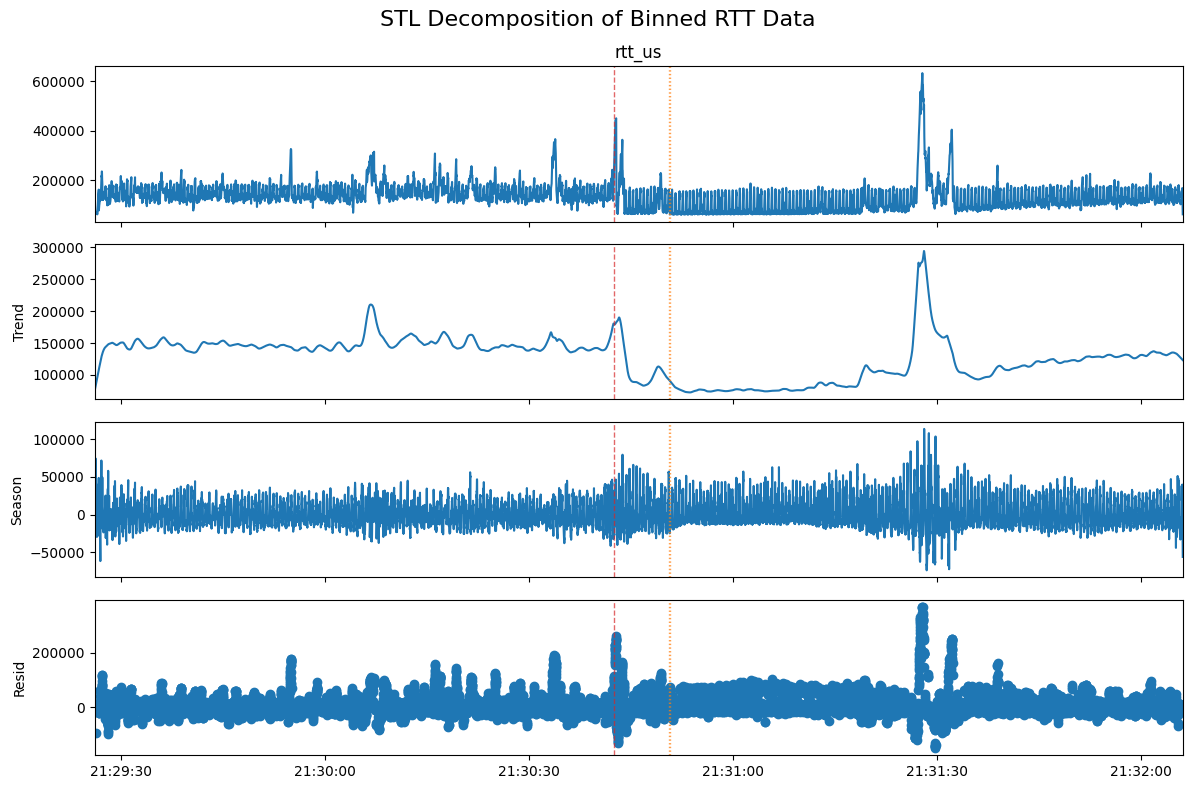

In [84]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt


# 2. Convert the Unix epoch timestamp to a Pandas DatetimeIndex
# 'unit=s' tells pandas the float represents seconds since the epoch.
rtt['timestamp'] = pd.to_datetime(rtt['ts_epoch'], unit='s')
rtt.set_index('timestamp', inplace=True)

# 3. Binning (Resampling)
# Group the irregular data into distinct 10-millisecond windows ('10ms').
# We use .mean() to average the 'rtt_us' of any packets that arrive in the same bin.
rtt_binned = rtt['rtt_us'].resample('10ms').mean()

# 4. Interpolation
# The resample operation creates NaN (Not a Number) values for 10ms bins
# where no packets arrived. STL will crash on NaNs, so we fill the gaps.
# 'linear' draws a straight line between the last known RTT and the next known RTT.
rtt_clean = rtt_binned.interpolate(method='linear')

# 5. STL Decomposition
# We must define a 'period' for STL. Since we binned at 10ms,
# a period of 100 represents a 1-second rolling cycle.
# robust=True makes it resistant to extreme outlier latency spikes.
stl = STL(rtt_clean, period=100, robust=True)
result = stl.fit()

# 6. Plot the results
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('STL Decomposition of Binned RTT Data', fontsize=16)
plt.tight_layout()

# Overlay congestion events on each STL subplot
for ax in fig.axes:
    _timeout_labeled = False
    _tripledup_labeled = False
    for _, row in cc_events.iterrows():
        t_dt = pd.to_datetime(row['Timestamp'], unit='s')
        if row['Event'] == 'TIMEOUT':
            label = 'Timeout' if not _timeout_labeled else None
            ax.axvline(t_dt, color='#d62728', linestyle='--', linewidth=1.0,
                       alpha=0.7, label=label)
            _timeout_labeled = True
        elif row['Event'] == 'TRIPLE_DUP_ACK':
            label = '3x Dup ACK' if not _tripledup_labeled else None
            ax.axvline(t_dt, color='#ff7f0e', linestyle=':', linewidth=1.0,
                       alpha=0.7, label=label)
            _tripledup_labeled = True

plt.show()

<Axes: ylabel='Frequency'>

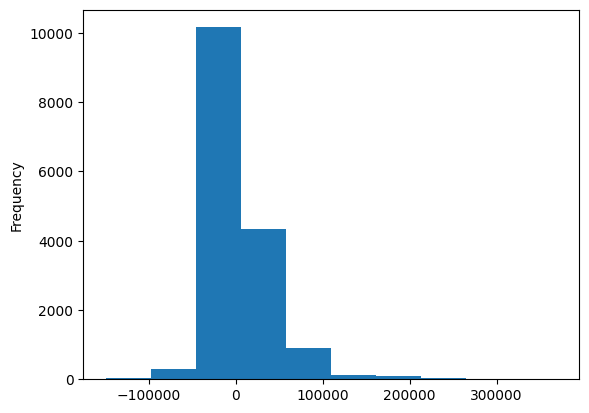

In [85]:
result.resid.plot.hist()

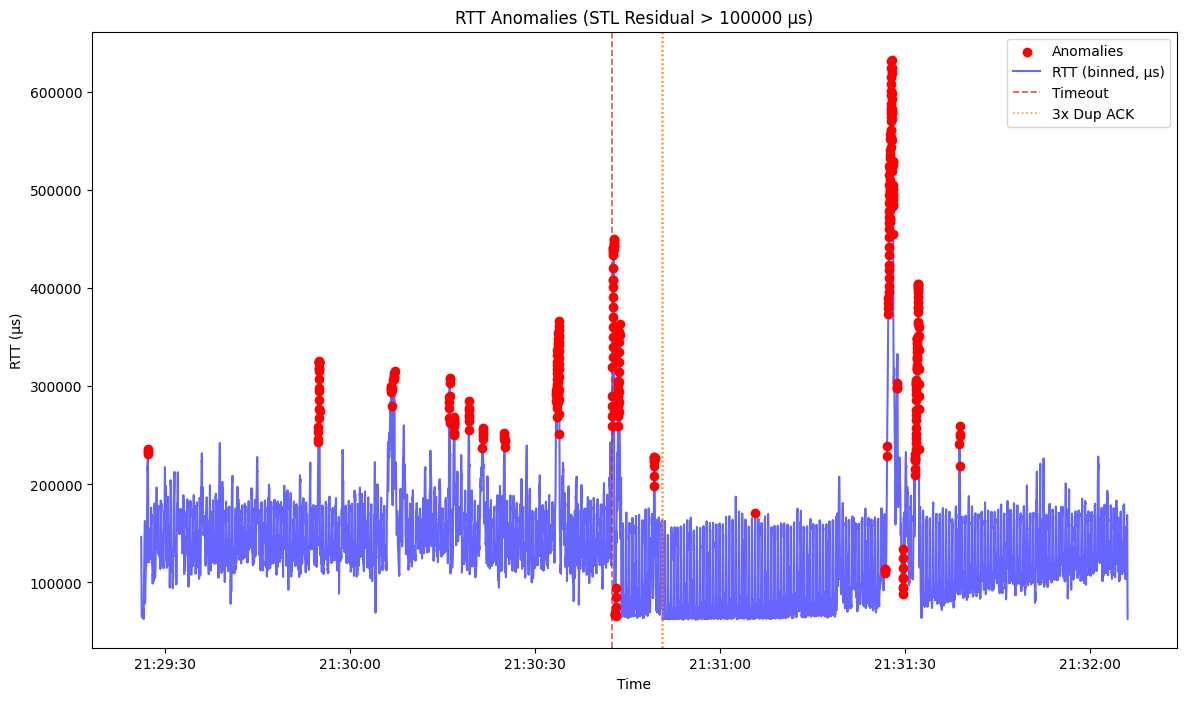

In [89]:
import matplotlib.pyplot as plt

threshold = 100000
anomalies_filter = result.resid.apply(lambda x: True if abs(x) > threshold else False)
anomalies = rtt_clean[anomalies_filter]

plt.figure(figsize=(14, 8))
plt.scatter(x=anomalies.index, y=anomalies, color="red", label="Anomalies", zorder=5)
plt.plot(rtt_clean.index, rtt_clean, color='blue', alpha=0.6, label='RTT (binned, µs)')

# Overlay congestion events
_timeout_labeled = False
_tripledup_labeled = False
for _, row in cc_events.iterrows():
    t_dt = pd.to_datetime(row['Timestamp'], unit='s')
    if row['Event'] == 'TIMEOUT':
        label = 'Timeout' if not _timeout_labeled else None
        plt.axvline(t_dt, color='#d62728', linestyle='--', linewidth=1.2,
                    alpha=0.8, label=label)
        _timeout_labeled = True
    elif row['Event'] == 'TRIPLE_DUP_ACK':
        label = '3x Dup ACK' if not _tripledup_labeled else None
        plt.axvline(t_dt, color='#ff7f0e', linestyle=':', linewidth=1.2,
                    alpha=0.8, label=label)
        _tripledup_labeled = True

plt.title(f'RTT Anomalies (STL Residual > {threshold} µs)')
plt.xlabel('Time')
plt.ylabel('RTT (µs)')
plt.legend()
plt.show()